Combined micromotion + secular fit (English):
  f_RF = 35.28 MHz (fixed); Ω_RF = 221.671 rad/μs
  y(t) = y_off + a_sec*cos(ω_sec*t + φ_sec) + a_micro*cos(Ω_RF*t + φ_micro)
  Fitted secular: f_sec = ω_sec/(2π) = 1.15829 MHz, a_sec = 0.000297736 μm, φ_sec = -208.207 rad
  Fitted micromotion: a_micro = -0.000757686 μm, φ_micro = 0.0501492 rad
  Offset y_off = 0.0491091 μm


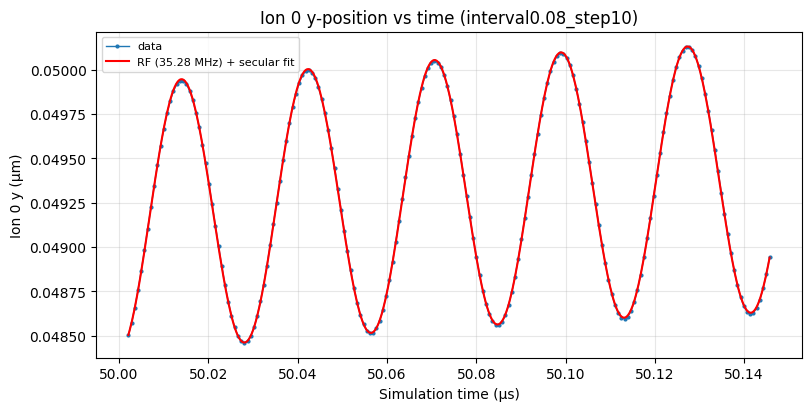

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Matches main.py output: t0{start μs .2f}_interval{interval}_step{step} (e.g. t030.00_...).
# Data lives under <repo>/continuous_sampling/... (this notebook is in motion_analysis/).
# Set to None to auto-pick the first matching t0*_interval*_step* subdirectory.
SAMPLE_RUN_DIR = None  # e.g. "t030.00_interval0.08_step10"

_here = Path.cwd()


def _continuous_sampling_search_bases():
    """Cwd may be repo root, motion_analysis/, or elsewhere — resolve likely output roots."""
    raw = (
        _here,
        _here / "continuous_sampling",
        _here.parent / "continuous_sampling",
    )
    out = []
    seen = set()
    for p in raw:
        key = p.resolve()
        if key not in seen:
            seen.add(key)
            out.append(p)
    return out


def _resolve_continuous_sampling_data_dir() -> Path:
    bases = _continuous_sampling_search_bases()
    if SAMPLE_RUN_DIR:
        for b in bases:
            p = b / SAMPLE_RUN_DIR
            if p.is_dir():
                return p
        return _here / SAMPLE_RUN_DIR
    for b in bases:
        subs = sorted(b.glob("t0*_interval*_step*"))
        if subs:
            return subs[0]
    if any(_here.glob("frame*.npz")):
        return _here
    raise FileNotFoundError(
        f"No continuous sampling run directory (searched {bases!r} from cwd {_here.resolve()}). "
        "Set SAMPLE_RUN_DIR or run main with --continuous-sampling."
    )


data_dir = _resolve_continuous_sampling_data_dir()

paths = sorted(data_dir.glob("frame*.npz"), key=lambda p: int(p.stem.replace("frame", "")))
if not paths:
    raise FileNotFoundError(f"No frame*.npz under {data_dir.resolve()}")

y_um_list = []
t_us_list = []
frame_indices = []
for p in paths:
    with np.load(p) as data:
        r = np.asarray(data["r"], dtype=float)
        t_us = float(np.asarray(data["t_us"]).ravel()[0]) if "t_us" in data else float("nan")
    frame_indices.append(int(p.stem.replace("frame", "")))
    y_um_list.append(float(r[0, 1]))
    t_us_list.append(t_us)

y_um = np.array(y_um_list)
t_us = np.array(t_us_list)
frame_index = np.array(frame_indices, dtype=int)

# --- Micromotion (fixed f_RF) + secular harmonic along y; t in μs
# Ω_RF = 2π f_RF (rad/μs) when f_RF is in MHz (same convention as before).
F_RF_MHZ = 35.28
OMEGA_RF_RAD_PER_US = 2 * np.pi * F_RF_MHZ


def y_ion_y(t_us, y_off, a_sec, omega_sec, phi_sec, a_micro, phi_micro):
    """
    y(t) = y_off
           + a_sec * cos(ω_sec * t + φ_sec)      # secular motion (ω_sec fitted, MHz via ω/(2π))
           + a_micro * cos(Ω_RF * t + φ_micro)    # micromotion at RF drive (Ω_RF fixed)
    All positions in μm; t in μs.
    """
    secular = a_sec * np.cos(omega_sec * t_us + phi_sec)
    micro = a_micro * np.cos(OMEGA_RF_RAD_PER_US * t_us + phi_micro)
    return y_off + secular + micro


use_time_axis = bool(np.all(np.isfinite(t_us)))
x_obs = t_us.astype(float) if use_time_axis else frame_index.astype(float)

ptp = float(np.ptp(y_um))
p0_y_off = float(np.mean(y_um))
p0_a_sec = 0.25 * ptp if ptp > 0 else 0.01
p0_omega_sec = 2 * np.pi * 0.5  # initial guess: 0.5 MHz secular (rad/μs)
p0_phi_sec = 0.0
p0_a_micro = 0.25 * ptp if ptp > 0 else 0.01
p0_phi_micro = 0.0

fit_ok = use_time_axis and len(x_obs) >= 8
popt, pcov = None, None
if fit_ok:
    try:
        popt, pcov = curve_fit(
            y_ion_y,
            x_obs,
            y_um,
            p0=[
                p0_y_off,
                p0_a_sec,
                p0_omega_sec,
                p0_phi_sec,
                p0_a_micro,
                p0_phi_micro,
            ],
            maxfev=100_000,
        )
    except RuntimeError:
        fit_ok = False

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
if use_time_axis:
    ax.plot(t_us, y_um, marker="o", ms=2, lw=1, label="data")
    ax.set_xlabel("Simulation time (μs)")
    ax.set_title(f"Ion 0 y-position vs time ({INTERVAL_DIR})")
else:
    ax.plot(frame_index, y_um, marker="o", ms=2, lw=1, label="data")
    ax.set_xlabel("frame index")
    ax.set_title(f"Ion 0 y-position vs frame index ({INTERVAL_DIR})")

if fit_ok and popt is not None:
    y_off, a_sec, omega_sec, phi_sec, a_micro, phi_micro = (float(p) for p in popt)
    x_fine = np.linspace(float(x_obs.min()), float(x_obs.max()), 500)
    y_fit = y_ion_y(
        x_fine,
        y_off,
        a_sec,
        omega_sec,
        phi_sec,
        a_micro,
        phi_micro,
    )
    ax.plot(
        x_fine,
        y_fit,
        "r-",
        lw=1.5,
        label=f"RF ({F_RF_MHZ:g} MHz) + secular fit",
    )
    ax.legend(loc="best", fontsize=8)

    f_sec_mhz = omega_sec / (2 * np.pi)
    print("Combined micromotion + secular fit (English):")
    print(f"  f_RF = {F_RF_MHZ:g} MHz (fixed); Ω_RF = {OMEGA_RF_RAD_PER_US:.6g} rad/μs")
    print(
        "  y(t) = y_off + a_sec*cos(ω_sec*t + φ_sec) + a_micro*cos(Ω_RF*t + φ_micro)"
    )
    print(
        f"  Fitted secular: f_sec = ω_sec/(2π) = {f_sec_mhz:.6g} MHz, "
        f"a_sec = {a_sec:.6g} μm, φ_sec = {phi_sec:.6g} rad"
    )
    print(
        f"  Fitted micromotion: a_micro = {a_micro:.6g} μm, φ_micro = {phi_micro:.6g} rad"
    )
    print(f"  Offset y_off = {y_off:.6g} μm")
else:
    if not use_time_axis:
        print(
            f"Fit skipped: need t_us in npz (RF fixed at {F_RF_MHZ:g} MHz)."
        )
    else:
        print(
            "Fit skipped: need ≥8 points and a successful least-squares solve "
            "(6 parameters: offset + secular 3 + micromotion 2)."
        )

ax.set_ylabel("Ion 0 y (μm)")
ax.grid(True, alpha=0.3)
plt.show()
